<a href="https://colab.research.google.com/github/shanilev123456/Final-Project-ds/blob/model-dev/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Libraries Import

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
!pip install ipython-autotime
%load_ext autotime

time: 367 µs (started: 2025-05-24 20:26:37 +00:00)


# Cleaned Data File Import

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv
time: 13.4 s (started: 2025-05-24 20:26:37 +00:00)


In [ ]:
df = pd.read_csv('dataset.csv')
df.head()

,Units,Area m2,Price per m2,Block_187.0,Block_325.0,Block_326.0,Block_375.0,Block_376.0,Block_390.0,Block_395.0,...,dist_to_park,is_park_within_radius,dist_to_mall,is_mall_within_radius,dist_to_supermarket,is_supermarket_within_radius,dist_to_beach,is_beach_within_radius,dist_to_place_of_worship,is_place_of_worship_within_radius
0,0.2,0.651852,0.246652,0,0,0,0,0,0,0,...,0.079120,0.0,0.880842,0.0,0.033427,1.0,0.450467,0.0,0.197408,0.0
1,0.2,0.650617,0.255311,0,0,0,0,0,0,0,...,0.079120,0.0,0.880842,0.0,0.033427,1.0,0.450467,0.0,0.197408,0.0
2,0.2,0.650617,0.215054,0,0,0,0,0,0,0,...,0.079120,0.0,0.880842,0.0,0.033427,1.0,0.450467,0.0,0.197408,0.0
3,0.0,0.170370,0.119238,0,0,0,0,0,0,0,...,0.732147,0.0,0.903616,0.0,0.675538,0.0,0.499842,0.0,0.332241,0.0
4,0.0,0.170370,0.120038,0,0,0,0,0,0,0,...,0.732147,0.0,0.903616,0.0,0.675538,0.0,0.499842,0.0,0.332241,0.0


time: 84.4 ms (started: 2025-05-24 20:26:50 +00:00)


In [ ]:
print(df.dtypes)

Units                                float64
Area m2                              float64
Price per m2                         float64
Block_187.0                            int64
Block_325.0                            int64
                                      ...   
is_supermarket_within_radius         float64
dist_to_beach                        float64
is_beach_within_radius               float64
dist_to_place_of_worship             float64
is_place_of_worship_within_radius    float64
Length: 381, dtype: object
time: 2.27 ms (started: 2025-05-24 20:26:50 +00:00)


# Data Splitting

In [ ]:
# target_column = "Price per m2"
# y = df[target_column]
# X = df.drop(columns=[target_column])

# X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

time: 299 µs (started: 2025-05-24 20:27:04 +00:00)


In [ ]:
df = df.dropna()
city_columns = [col for col in df.columns if col.startswith("City_")]
df['city'] = df[city_columns].idxmax(axis=1).str.replace('City_', '')

city_counts = df['city'].value_counts()
valid_cities = city_counts[city_counts > 1].index
df = df[df['city'].isin(valid_cities)].copy()


city_columns = [col for col in df.columns if col.startswith("City_")]

target_column = "Price per m2"
y = df[target_column]
X = df.drop(columns=[target_column])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['city']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42,
    stratify=X_train_full['city']
)

X_train = X_train.drop(columns=['city'])
X_val = X_val.drop(columns=['city'])
X_test = X_test.drop(columns=['city'])

time: 43.3 ms (started: 2025-05-24 20:27:04 +00:00)


<ipython-input-6-662d93a32ebb>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['city'] = df[city_columns].idxmax(axis=1).str.replace('City_', '')


In [ ]:
if isinstance(X_train, pd.DataFrame):
    X_train = X_train.values
if isinstance(X_val, pd.DataFrame):
    X_val = X_val.values
if isinstance(X_test, pd.DataFrame):
    X_test = X_test.values

time: 3.98 ms (started: 2025-05-24 20:27:04 +00:00)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda
time: 22.6 ms (started: 2025-05-24 20:27:04 +00:00)


In [ ]:
X_train = X_train.astype(float)
X_val = X_val.astype(float)
X_test = X_test.astype(float)

X_train = np.array(X_train, dtype=np.float32)
X_val = np.array(X_val, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

X_train_tensor = torch.tensor(X_train.astype(np.float32)).to(device)
X_val_tensor = torch.tensor(X_val.astype(np.float32)).to(device)
X_test_tensor = torch.tensor(X_test.astype(np.float32)).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

time: 220 ms (started: 2025-05-24 20:27:04 +00:00)


#EX1

In [ ]:
class Model_EX1(nn.Module):
    def __init__(self, input_dim):
        super(Model_EX1, self).__init__()
        self.model = nn.Sequential(

            # -------------------Ex.1-------------------------- #

            # nn.Linear(input_dim, 512),
            # nn.BatchNorm1d(512),
            # nn.ReLU(),
            # nn.Linear(512, 256),
            # nn.BatchNorm1d(256),
            # nn.ReLU(),
            # nn.Linear(256, 128),
            # nn.ReLU(),
            # nn.Linear(128, 64),
            # nn.ReLU(),
            # nn.Linear(64, 1)

            # -------------------Ex.2-------------------------- #

            # nn.Linear(input_dim, 1024),
            # nn.BatchNorm1d(1024),
            # nn.ReLU(),

            # nn.Linear(1024, 512),
            # nn.BatchNorm1d(512),
            # nn.ReLU(),

            # nn.Linear(512, 256),
            # nn.BatchNorm1d(256),
            # nn.ReLU(),

            # nn.Linear(256, 128),
            # nn.BatchNorm1d(128),
            # nn.ReLU(),

            # nn.Linear(128, 1)

            # -------------------Ex.3-------------------------- #
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)

        )

    def forward(self, x):
        return self.model(x)

time: 8.41 ms (started: 2025-05-24 20:27:19 +00:00)


In [ ]:
model1 = Model_EX1(X_train_tensor.shape[1]).to(device)
criterion = nn.MSELoss()
# criterion = nn.
# optimizer = optim.Adam(model1.parameters(), lr=0.001, weight_decay=1e-3)
optimizer = optim.AdamW(model1.parameters(), lr=0.0005, weight_decay=0.001)
# optimizer = optim.Adam(model1.parameters(), lr=0.0001, weight_decay=1e-3)

from torch.optim.lr_scheduler import StepLR
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

time: 3.15 s (started: 2025-05-24 20:27:19 +00:00)


In [ ]:
epochs = 50
train_loss1, val_loss1 = [], []
train_r21, val_r21     = [], []
for epoch in range(epochs):
    # train
    model1.train()
    epoch_loss, preds, targs = 0, [], []
    for batch_X, batch_y in train_loader:
        if batch_X.size(0) == 1:
            continue
        optimizer.zero_grad()
        output = model1(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    average_loss = epoch_loss / len(train_loader)
    train_loss1.append(average_loss)

     # --- חישוב R² רק במצב eval (ללא Dropout) ---
    model1.eval()
    with torch.no_grad():
        preds_train = model1(X_train_tensor).cpu().numpy().flatten()
        targs_train = y_train_tensor.cpu().numpy().flatten()
    train_r21.append(r2_score(targs_train, preds_train))


    scheduler.step()

    # val
    model1.eval()
    with torch.no_grad():
        if X_val_tensor.size(0) > 1:
            val_output = model1(X_val_tensor)
            val_loss = criterion(val_output, y_val_tensor).item()
            preds_v = val_output.cpu().numpy().flatten()
            targs_v = y_val_tensor.cpu().numpy().flatten()
        else:
            val_loss = float('inf')
    val_loss1.append(val_loss)
    val_r21.append(r2_score(targs_v,preds_v))

    print(f"Epoch {epoch}: Train Loss: {average_loss:.6f}, Val Loss: {val_loss:.6f}, "
          f"Train R2: {train_r21[-1]:.4f}, Val R2: {val_r21[-1]:.4f}")

Epoch 0: Train Loss: 0.138163, Val Loss: 0.014711, Train R2: 0.1689, Val R2: 0.1681
Epoch 1: Train Loss: 0.079078, Val Loss: 0.009593, Train R2: 0.4825, Val R2: 0.4575
Epoch 2: Train Loss: 0.054479, Val Loss: 0.007250, Train R2: 0.6038, Val R2: 0.5900
Epoch 3: Train Loss: 0.044674, Val Loss: 0.006462, Train R2: 0.6537, Val R2: 0.6346
Epoch 4: Train Loss: 0.033904, Val Loss: 0.004577, Train R2: 0.7624, Val R2: 0.7412
Epoch 5: Train Loss: 0.025786, Val Loss: 0.003898, Train R2: 0.8044, Val R2: 0.7795
Epoch 6: Train Loss: 0.021863, Val Loss: 0.003716, Train R2: 0.8199, Val R2: 0.7899
Epoch 7: Train Loss: 0.018094, Val Loss: 0.003736, Train R2: 0.8297, Val R2: 0.7887
Epoch 8: Train Loss: 0.014195, Val Loss: 0.003191, Train R2: 0.8597, Val R2: 0.8195
Epoch 9: Train Loss: 0.011728, Val Loss: 0.003276, Train R2: 0.8561, Val R2: 0.8148
Epoch 10: Train Loss: 0.010308, Val Loss: 0.003048, Train R2: 0.8733, Val R2: 0.8276
Epoch 11: Train Loss: 0.009548, Val Loss: 0.003107, Train R2: 0.8614, Val R

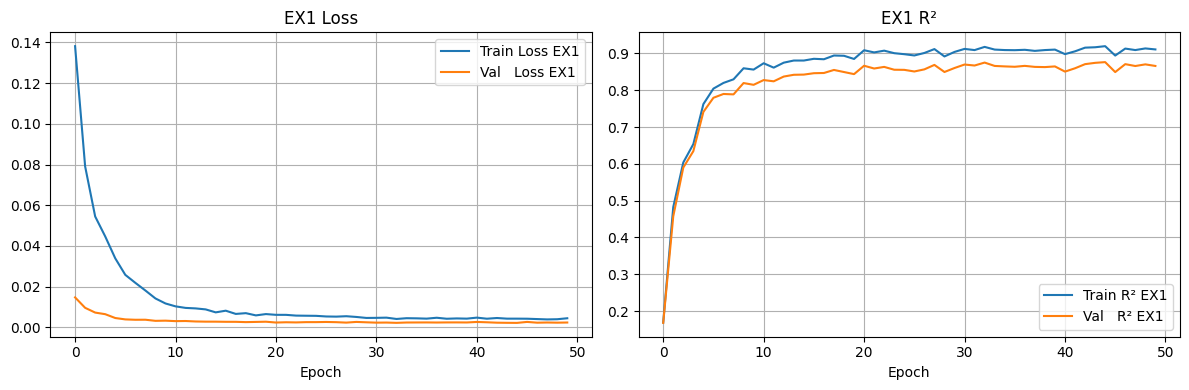

time: 335 ms (started: 2025-05-24 20:27:31 +00:00)


In [ ]:
# === CELL – GRAPHS EX1 ===
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss1, label="Train Loss EX1")
plt.plot(val_loss1,   label="Val   Loss EX1")
plt.title("EX1 Loss"); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_r21, label="Train R² EX1")
plt.plot(val_r21,   label="Val   R² EX1")
plt.title("EX1 R²"); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)

plt.tight_layout(); plt.show()

#EX2

In [ ]:
class ModelExperiment2(nn.Module):
    def __init__(self, input_dim):
        super(ModelExperiment2, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

time: 1.02 ms (started: 2025-05-24 20:27:32 +00:00)


In [ ]:
model2 = ModelExperiment2(X_train_tensor.shape[1]).to(device)
criterion = nn.MSELoss()
# optimizer = optim.Adam(model2.parameters(), lr=0.00005, weight_decay=1e-3)
# optimizer = optim.Adam(model2.parameters(), lr=0.00005)
optimizer = optim.Adam(model2.parameters(), lr=0.0001)
scheduler = StepLR(optimizer, step_size=8, gamma=0.6)

time: 8.99 ms (started: 2025-05-24 20:27:32 +00:00)


In [ ]:
epochs = 50
train_loss2, val_loss2 = [], []
train_r22,   val_r22   = [], []
for epoch in range(epochs):
    # train
    model2.train()
    epoch_loss, preds, targs = 0.0, [], []
    for batch_X, batch_y in train_loader:
        if batch_X.size(0) == 1:
            continue
        optimizer.zero_grad()
        output = model2(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    average_loss = epoch_loss / len(train_loader)
    train_loss2.append(average_loss)

    # --- חישוב R² רק במצב eval (ללא Dropout) ---
    model2.eval()
    with torch.no_grad():
        preds_train = model2(X_train_tensor).cpu().numpy().flatten()
        targs_train = y_train_tensor.cpu().numpy().flatten()
    train_r22.append(r2_score(targs_train, preds_train))

    scheduler.step()

    # val
    model2.eval()
    with torch.no_grad():
        if X_val_tensor.size(0) > 1:
            val_output = model2(X_val_tensor)
            val_loss = criterion(val_output, y_val_tensor).item()
            preds_v = val_output.cpu().numpy().flatten()
            targs_v = y_val_tensor.cpu().numpy().flatten()
        else:
            val_loss = float('inf')
    val_loss2.append(val_loss)
    val_r22.append(r2_score(targs_v,preds_v))

    print(f"Epoch {epoch}: Train Loss: {average_loss:.6f}, Val Loss: {val_loss:.6f}, "
          f"Train R2: {train_r22[-1]:.4f}, Val R2: {val_r22[-1]:.4f}")

Epoch 0: Train Loss: 0.145415, Val Loss: 0.039604, Train R2: -1.2936, Val R2: -1.2397
Epoch 1: Train Loss: 0.094874, Val Loss: 0.016988, Train R2: -0.0188, Val R2: 0.0393
Epoch 2: Train Loss: 0.077830, Val Loss: 0.010964, Train R2: 0.3854, Val R2: 0.3800
Epoch 3: Train Loss: 0.070868, Val Loss: 0.009628, Train R2: 0.4241, Val R2: 0.4555
Epoch 4: Train Loss: 0.056023, Val Loss: 0.008567, Train R2: 0.4802, Val R2: 0.5155
Epoch 5: Train Loss: 0.049838, Val Loss: 0.006042, Train R2: 0.6241, Val R2: 0.6583
Epoch 6: Train Loss: 0.045377, Val Loss: 0.005949, Train R2: 0.6610, Val R2: 0.6635
Epoch 7: Train Loss: 0.041833, Val Loss: 0.005582, Train R2: 0.7017, Val R2: 0.6843
Epoch 8: Train Loss: 0.040541, Val Loss: 0.006294, Train R2: 0.6835, Val R2: 0.6441
Epoch 9: Train Loss: 0.043033, Val Loss: 0.005776, Train R2: 0.7213, Val R2: 0.6734
Epoch 10: Train Loss: 0.040585, Val Loss: 0.005167, Train R2: 0.7654, Val R2: 0.7078
Epoch 11: Train Loss: 0.035996, Val Loss: 0.005005, Train R2: 0.7697, Va

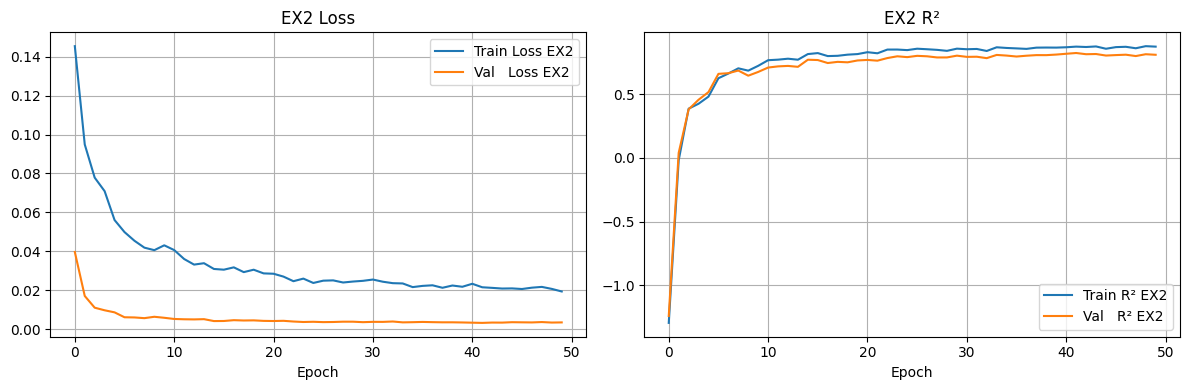

time: 279 ms (started: 2025-05-24 20:27:40 +00:00)


In [ ]:
# === CELL – GRAPHS EX2 ===
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss2, label="Train Loss EX2")
plt.plot(val_loss2,   label="Val   Loss EX2")
plt.title("EX2 Loss"); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_r22, label="Train R² EX2")
plt.plot(val_r22,   label="Val   R² EX2")
plt.title("EX2 R²"); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)

plt.tight_layout(); plt.show()


# Comaprison EX1 VS EX2

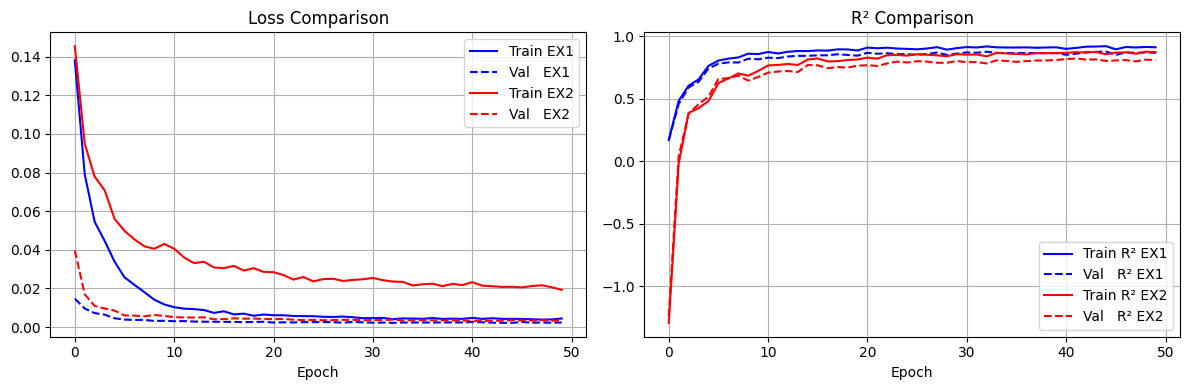

time: 312 ms (started: 2025-05-24 20:27:40 +00:00)


In [ ]:
# === CELL – COMPARISON EX1 vs EX2 ===
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss1, 'b-', label="Train EX1")
plt.plot(val_loss1,   'b--',label="Val   EX1")
plt.plot(train_loss2, 'r-', label="Train EX2")
plt.plot(val_loss2,   'r--',label="Val   EX2")
plt.title("Loss Comparison"); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_r21, 'b-', label="Train R² EX1")
plt.plot(val_r21,   'b--',label="Val   R² EX1")
plt.plot(train_r22, 'r-', label="Train R² EX2")
plt.plot(val_r22,   'r--',label="Val   R² EX2")
plt.title("R² Comparison"); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)

plt.tight_layout(); plt.show()


# Evaluation

In [ ]:
def evaluate_model(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor, y_test_tensor):
    model.eval()
    with torch.no_grad():
        train_predictions = model(X_train_tensor)
        y_train_pred = train_predictions.cpu().numpy()
        y_train_true = y_train_tensor.cpu().numpy()

        train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
        train_mae = mean_absolute_error(y_train_true, y_train_pred)
        train_r2 = r2_score(y_train_true, y_train_pred)

        print(f"\nTrain RMSE: {train_rmse:.6f}")
        print(f"Train MAE: {train_mae:.6f}")
        print(f"Train R²: {train_r2:.4f}")

        val_predictions = model(X_val_tensor)
        y_val_pred = val_predictions.cpu().numpy()
        y_val_true = y_val_tensor.cpu().numpy()

        val_rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
        val_mae = mean_absolute_error(y_val_true, y_val_pred)
        val_r2 = r2_score(y_val_true, y_val_pred)

        print(f"\nVal RMSE: {val_rmse:.6f}")
        print(f"Val MAE: {val_mae:.6f}")
        print(f"Val R²: {val_r2:.4f}")

        test_predictions = model(X_test_tensor)
        y_test_pred = test_predictions.cpu().numpy()
        y_test_true = y_test_tensor.cpu().numpy()

        test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
        test_mae = mean_absolute_error(y_test_true, y_test_pred)
        test_r2 = r2_score(y_test_true, y_test_pred)

        print(f"\nTest RMSE: {test_rmse:.6f}")
        print(f"Test MAE: {test_mae:.6f}")
        print(f"Test R²: {test_r2:.4f}")

time: 3.43 ms (started: 2025-05-24 20:27:41 +00:00)


In [ ]:
# Evaluate EX1
evaluate_model(model1, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor, y_test_tensor)


Train RMSE: 0.039321
Train MAE: 0.026634
Train R²: 0.9109

Val RMSE: 0.048684
Val MAE: 0.028039
Val R²: 0.8660

Test RMSE: 0.052706
Test MAE: 0.029657
Test R²: 0.8505
time: 13.5 ms (started: 2025-05-24 20:27:41 +00:00)


In [ ]:
# Evaluate EX2
evaluate_model(model2, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor, y_test_tensor)


Train RMSE: 0.047164
Train MAE: 0.034284
Train R²: 0.8718

Val RMSE: 0.058285
Val MAE: 0.039050
Val R²: 0.8079

Test RMSE: 0.055573
Test MAE: 0.036944
Test R²: 0.8338
time: 9.02 ms (started: 2025-05-24 20:27:41 +00:00)


#Graphs - True vs Predicted

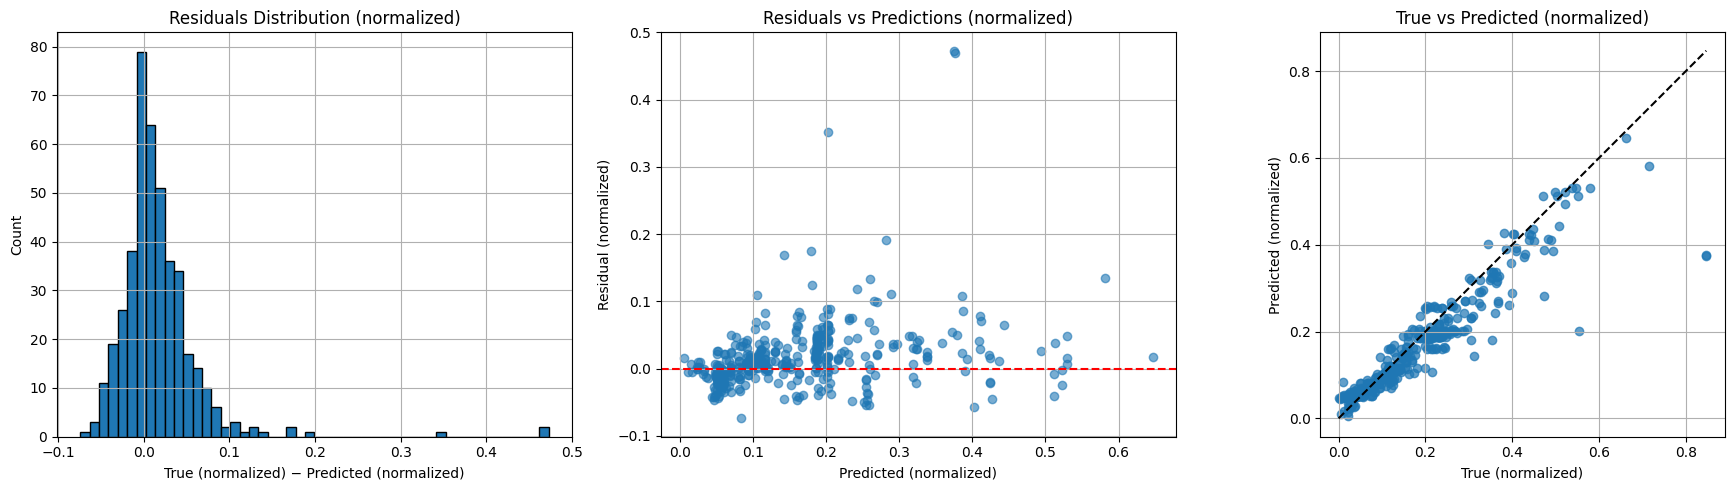

time: 583 ms (started: 2025-05-24 20:35:04 +00:00)


In [ ]:
import matplotlib.pyplot as plt

# Compute normalized predictions and ground truths without inverse scaling
model1.eval()
with torch.no_grad():
    preds_norm = model1(X_test_tensor).cpu().numpy().flatten()
    truths_norm = y_test_tensor.cpu().numpy().flatten()

# Compute residuals in normalized space
residuals_norm = truths_norm - preds_norm

# Plot three related charts side by side
plt.figure(figsize=(18, 5))

# 1. Residuals Distribution (normalized)
plt.subplot(1, 3, 1)
plt.hist(residuals_norm, bins=50, edgecolor='k')
plt.title('Residuals Distribution (normalized)')
plt.xlabel('True (normalized) − Predicted (normalized)')
plt.ylabel('Count')
plt.grid(True)

# 2. Residuals vs. Predictions (normalized)
plt.subplot(1, 3, 2)
plt.scatter(preds_norm, residuals_norm, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predictions (normalized)')
plt.xlabel('Predicted (normalized)')
plt.ylabel('Residual (normalized)')
plt.grid(True)

# 3. True vs. Predicted Scatter with 45° reference line (normalized)
plt.subplot(1, 3, 3)
plt.scatter(truths_norm, preds_norm, alpha=0.7)
mn, mx = min(truths_norm.min(), preds_norm.min()), max(truths_norm.max(), preds_norm.max())
plt.plot([mn, mx], [mn, mx], 'k--')  # diagonal line for perfect prediction
plt.title('True vs Predicted (normalized)')
plt.xlabel('True (normalized)')
plt.ylabel('Predicted (normalized)')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


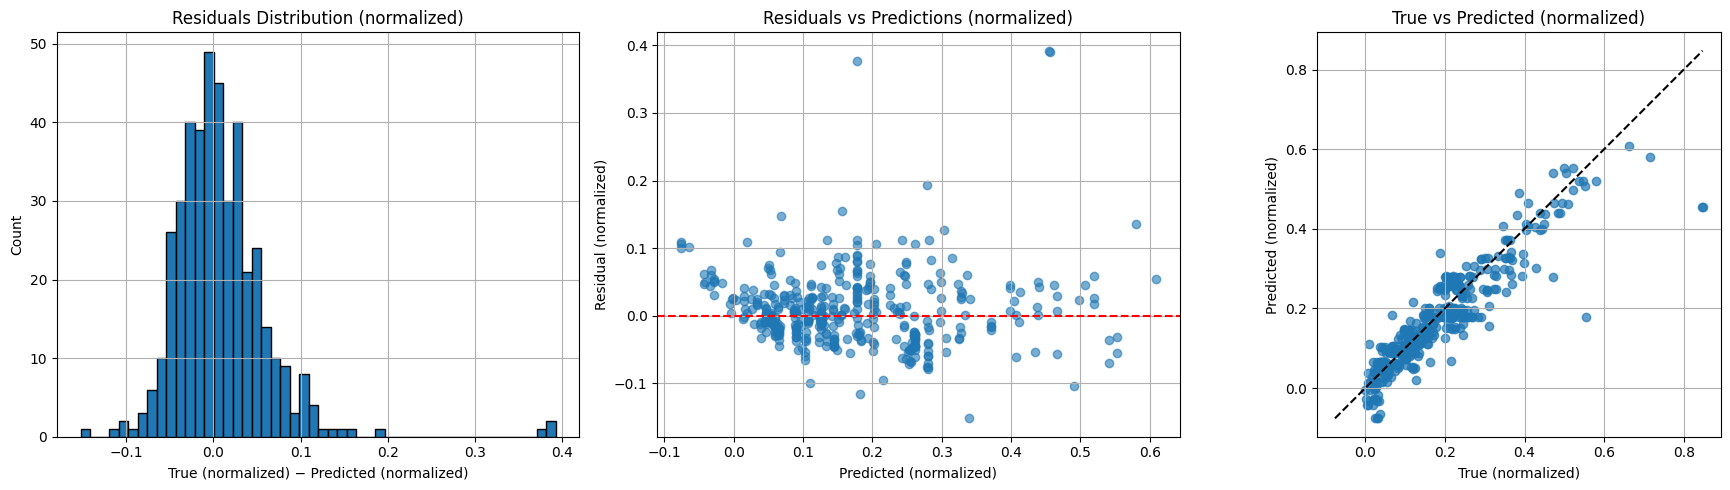

time: 488 ms (started: 2025-05-24 20:27:41 +00:00)


In [ ]:
import matplotlib.pyplot as plt

# Compute normalized predictions and ground truths without inverse scaling
model2.eval()
with torch.no_grad():
    preds_norm = model2(X_test_tensor).cpu().numpy().flatten()
    truths_norm = y_test_tensor.cpu().numpy().flatten()

# Compute residuals in normalized space
residuals_norm = truths_norm - preds_norm

# Plot three related charts side by side
plt.figure(figsize=(18, 5))

# 1. Residuals Distribution (normalized)
plt.subplot(1, 3, 1)
plt.hist(residuals_norm, bins=50, edgecolor='k')
plt.title('Residuals Distribution (normalized)')
plt.xlabel('True (normalized) − Predicted (normalized)')
plt.ylabel('Count')
plt.grid(True)

# 2. Residuals vs. Predictions (normalized)
plt.subplot(1, 3, 2)
plt.scatter(preds_norm, residuals_norm, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predictions (normalized)')
plt.xlabel('Predicted (normalized)')
plt.ylabel('Residual (normalized)')
plt.grid(True)

# 3. True vs. Predicted Scatter with 45° reference line (normalized)
plt.subplot(1, 3, 3)
plt.scatter(truths_norm, preds_norm, alpha=0.7)
mn, mx = min(truths_norm.min(), preds_norm.min()), max(truths_norm.max(), preds_norm.max())
plt.plot([mn, mx], [mn, mx], 'k--')  # diagonal line for perfect prediction
plt.title('True vs Predicted (normalized)')
plt.xlabel('True (normalized)')
plt.ylabel('Predicted (normalized)')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


#Error Testing

In [ ]:
import json
with open("price_minmax.json", "r", encoding="utf-8") as f:
    scaler_data = json.load(f)

price_per_m2_min = scaler_data["price_per_m2_min"]
price_per_m2_max = scaler_data["price_per_m2_max"]

In [ ]:
def inverse_transform(normalized_values, min_value, max_value):
    original_values = normalized_values * (max_value - min_value) + min_value
    return original_values

In [ ]:
from sklearn.metrics import mean_absolute_error

model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor).cpu().numpy().flatten()
    y_test_true = y_test_tensor.cpu().numpy().flatten()

y_test_pred_original = inverse_transform(test_predictions, price_per_m2_min, price_per_m2_max)
y_test_true_original = inverse_transform(y_test_true, price_per_m2_min, price_per_m2_max)

mae_original = mean_absolute_error(y_test_true_original, y_test_pred_original)
print(f"\nOriginal Scale MAE: {mae_original:.2f} שקלים למ\"ר")

In [ ]:
import numpy as np

mean_price_per_m2 = np.mean(y_test_true_original)

mae_percentage = (mae_original / mean_price_per_m2) * 100

print(f"\nMean of Price per m2: {mean_price_per_m2:.2f} שקלים למ\"ר")
print(f"MAE as a percentage of the Mean: {mae_percentage:.2f}%")

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

model.eval()

with torch.no_grad():
    train_predictions = model(X_train_tensor).cpu().numpy().flatten()
    y_train_true = y_train_tensor.cpu().numpy().flatten()

    val_predictions = model(X_val_tensor).cpu().numpy().flatten()
    y_val_true = y_val_tensor.cpu().numpy().flatten()

    test_predictions = model(X_test_tensor).cpu().numpy().flatten()
    y_test_true = y_test_tensor.cpu().numpy().flatten()

y_train_pred_original = inverse_transform(train_predictions, price_per_m2_min, price_per_m2_max)
y_train_true_original = inverse_transform(y_train_true, price_per_m2_min, price_per_m2_max)

y_val_pred_original = inverse_transform(val_predictions, price_per_m2_min, price_per_m2_max)
y_val_true_original = inverse_transform(y_val_true, price_per_m2_min, price_per_m2_max)

y_test_pred_original = inverse_transform(test_predictions, price_per_m2_min, price_per_m2_max)
y_test_true_original = inverse_transform(y_test_true, price_per_m2_min, price_per_m2_max)

mae_train = mean_absolute_error(y_train_true_original, y_train_pred_original)
mae_val = mean_absolute_error(y_val_true_original, y_val_pred_original)
mae_test = mean_absolute_error(y_test_true_original, y_test_pred_original)

print(f"\nTrain MAE: {mae_train:.2f} שקלים למ\"ר")
print(f"Validation MAE: {mae_val:.2f} שקלים למ\"ר")
print(f"Test MAE: {mae_test:.2f} שקלים למ\"ר")

mean_price_per_m2_train = np.mean(y_train_true_original)
mean_price_per_m2_val = np.mean(y_val_true_original)
mean_price_per_m2_test = np.mean(y_test_true_original)

mae_percentage_train = (mae_train / mean_price_per_m2_train) * 100
mae_percentage_val = (mae_val / mean_price_per_m2_val) * 100
mae_percentage_test = (mae_test / mean_price_per_m2_test) * 100

print(f"\nTrain MAE as a percentage of the Mean: {mae_percentage_train:.2f}%")
print(f"Validation MAE as a percentage of the Mean: {mae_percentage_val:.2f}%")
print(f"Test MAE as a percentage of the Mean: {mae_percentage_test:.2f}%")

#Feature Importance

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score
import torch

class PytorchModelWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def fit(self, X, y=None):
        pass

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.model.eval()
        with torch.no_grad():
            predictions = self.model(X_tensor).cpu().numpy().flatten()
        return predictions

time: 1.52 ms (started: 2025-04-22 11:36:22 +00:00)


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

wrapped_model = PytorchModelWrapper(model=model, device=device)

time: 548 µs (started: 2025-04-22 11:36:22 +00:00)


In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(wrapped_model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

print(f"R² Scores for each fold: {scores}")
print(f"Average R² Score: {np.mean(scores)}")

R² Scores for each fold: [0.93144763 0.94394747 0.94812167 0.93409181 0.93551237]
Average R² Score: 0.9386241898713934
time: 9.14 s (started: 2025-04-22 11:36:22 +00:00)


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

wrapped_model = PytorchModelWrapper(model=model, device=device)

result = permutation_importance(
    wrapped_model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance Mean": result.importances_mean,
    "Importance Std": result.importances_std
}).sort_values(by="Importance Mean", ascending=False)

print(feature_importances)

                           Feature  Importance Mean  Importance Std
3096           Committee_year_2022         0.102852        0.005189
3095           Committee_year_2021         0.082078        0.003705
3109         City_באר שבע , כלניות         0.076416        0.007550
3098           Committee_year_2024         0.075828        0.004859
3065             Committee_month_1         0.045530        0.002084
...                            ...              ...             ...
3168  City_שדרות , שכונת צפון מרכז        -0.000915        0.000580
1361                 Parcel_1155.0        -0.000933        0.001985
51                   Block_38399.0        -0.001117        0.000309
228                Section_38399.0        -0.001117        0.000309
3114       City_באר שבע , נאות לון        -0.001912        0.000611

[3170 rows x 3 columns]
time: 4min 43s (started: 2025-04-22 11:36:32 +00:00)


# Test environment

In [ ]:
import pandas as pd
import torch
import tkinter as tk
from tkinter import simpledialog, messagebox

time: 59.9 ms (started: 2025-04-20 16:15:56 +00:00)


In [ ]:
uploaded = files.upload()

Saving cleaned_data.csv to cleaned_data (1).csv
time: 34min 24s (started: 2025-04-20 16:15:57 +00:00)


In [ ]:
import json

with open("scaler_minmax.json", "r", encoding="utf-8") as f:
    scaler_minmax = json.load(f)

price_min = scaler_minmax["Price per m2"]["min"]
price_max = scaler_minmax["Price per m2"]["max"]

FileNotFoundError: [Errno 2] No such file or directory: 'scaler_minmax.json'

time: 25.9 ms (started: 2025-04-20 16:50:21 +00:00)


In [ ]:
# בהמשך נכון להסתכל גם על תאריך - שנה כפקטור שמשנה את המחיר

def predict_price(user_input: dict, model, X_columns, scaler_minmax: dict) -> float:
    """
    :param user_input: Dictionary containing input features:
        {
            'City': 'city_name',
            # 'Block': 123,
            # 'Parcel': 456,
            'Area m2': 250
        }
    :param model: DeepFCNN model.
    :param X_columns: Columns from the original training DataFrame.
    :return: Predicted price per square meter.
    """

    # Initialize input df
    input_df = pd.DataFrame([0] * len(X_columns), index=X_columns).T
    input_df.loc[0] = 0

    # Filter user's inputs - separate city and neighborhood
    city = user_input.get('City', None)
    # neighborhood = user_input.get('Neighborhood', None)

    def find_column_by_substring(columns, substring_list):
        """
        :return: Column whose substring is in substring_list >> for city.
        """
        for col in columns:
            if all(sub.lower() in col.lower() for sub in substring_list if sub):
                return col
        return None

    # Finding column contains both city and neighborhood
    if city:
        col_found_city_only = find_column_by_substring(input_df.columns, [city])
        if col_found_city_only:
            input_df[col_found_city_only] = 1
        else:
            print(f"City '{city}' cannot be found in DB.")

    # Precise query with other given parameters.

    if "Area m2" in user_input and "Area m2" in X_columns:
        area_min = scaler_minmax["Area m2"]["min"]
        area_max = scaler_minmax["Area m2"]["max"]
        raw_area = float(user_input["Area m2"])
        if area_max > area_min:
            input_df["Area m2"] = (raw_area - area_min) / (area_max - area_min)
        else:
            input_df["Area m2"] = 0.0

    #Exeption in case no values have got
    if input_df.empty:
        raise ValueError("No records were found match to the query.")

    input_tensor = torch.tensor(input_df.values, dtype=torch.float32).to(device)

    # Prediction
    model.eval()
    with torch.no_grad():
        prediction = model(input_tensor).item()

    price_min = scaler_minmax["Price per m2"]["min"]
    price_max = scaler_minmax["Price per m2"]["max"]
    predicted_price_per_m2 = prediction * (price_max - price_min) + price_min

    return predicted_price_per_m2

In [ ]:
# Example on existing record
user_input = {
    "City": "באר שבע",
    "Area m2": 500
}
predicted_price_per_m2 = predict_price(
    user_input,
    model,
    X.columns,
    scaler_minmax
)

print(f"Predicted price per m²: {predicted_price_per_m2:,.2f} ₪")
total_price = predicted_price_per_m2 * user_input['Area m2']
print(f"\ntotal price for this area size: {total_price:,.2f} ₪")

## Interactive input terminal


In [ ]:
import os

def interactive_terminal(model, X_columns, device, minmax_path="price_minmax.json"):

    if not os.path.exists(minmax_path):
        print(f"Error: file {minmax_path} not found.")
        return

    with open(minmax_path, "r", encoding="utf-8") as f:
        price_range = json.load(f)

    price_per_m2_min = price_range["price_per_m2_min"]
    price_per_m2_max = price_range["price_per_m2_max"]

    while True:
        print("\n------ Land Price Forecast System -------")

        # user input
        city_name = input("Please enter city name [ For example- אשקלון ] or 'Exit':").strip()
        if city_name.lower() == 'exit':
            print ("Closing terminal.")
            break

        area_size_input = input("Please enter Area size in M2: ").strip()
        try:
            area_size = float(area_size_input)
        except ValueError:
            print(f"Area size {area_size_input} is not valid. Try again.")
            continue

        # DataFrame for the receiving values
        # input_df = pd.DataFrame(columns=X_columns)
        input_df = pd.DataFrame([0] * len(X_columns), index=X_columns).T
        input_df.loc[0] = 0
        input_df['Area m2'] = area_size

        city_column = f'City_{city_name}'
        if city_column in input_df.columns:
            input_df[city_column] = 1
        else:
            print(f"City '{city_name}' not found in dataset. Try another.")
            continue

        # input_tensor = torch.tensor(input_df, dtype=torch.float32).to(device)
        input_tensor = torch.tensor(input_df.values, dtype=torch.float32).to(device)

        # Prediction
        model.eval()
        with torch.no_grad():
            prediction = model(input_tensor).item()

        # Inverse transformation

        price_min = scaler_minmax["Price per m2"]["min"]
        price_max = scaler_minmax["Price per m2"]["max"]
        predicted_price_per_m2 = prediction * (price_max - price_min) + price_min

        print(f"\nThe estimated *price per m²*  for {area_size:.0f}m² in {city_name} is: {predicted_price_per_m2:,.2f} ₪")
        break

### Other option for terminal


In [ ]:
# def interactive_terminal(scaler, model, X_columns, device):

#     root = tk.Tk()
#     root.withdraw()

#     city_name = simpledialog.askstring("Input", "הזן את שם העיר:")
#     neighborhood = simpledialog.askstring("Input", "הזן את שם השכונה (לא חובה):")
#     area_size = simpledialog.askfloat("Input", "הזן את גודל השטח במ\"ר:")
#     block = simpledialog.askfloat("Input", "הזן את מספר הגוש (לא חובה):")
#     parcel = simpledialog.askfloat("Input", "הזן את מספר החלקה (לא חובה):")

#     root.destroy()

#     user_input = {
#         'City': city_name,
#         'Neighborhood': neighborhood,
#         'Area m2': area_size,
#         'Block': block,
#         'Parcel': parcel
#     }

#     user_input = {k: v for k, v in user_input.items() if v is not None}

#     try:
#         prediction = predict_price(user_input, scaler, model, X_columns, device)

#         #inverse transformation
#         # StandardScaler
#         original_prediction = prediction * scaler.scale_[-1] + scaler.mean_[-1]

#         # Min- Max Scaler
#         # original_prediction = prediction * (scaler.data_max_[-1] - scaler.data_min_[-1]) + scaler.data_min_[-1]

#         result_root = tk.Tk()
#         result_root.withdraw()
#         messagebox.showinfo("תחזית המחיר",f"The estimated price for M2  is {original_prediction:.2f}")
#         result_root.destroy()

#     except ValueError as e:
#         error_root = tk.Tk()
#         error_root.withdraw()
#         messagebox.showerror("Output Error.", str(e))
#         error_root.destroy()

#     root.destroy()

In [ ]:
# interactive_terminal(DeepFCNN,X.columns, device, minmax_path="price_minmax.json")